In [1]:
# Robyn Baumann
# AST4762 Practicum 2
# Sep 18 2026


In [2]:
# load necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [3]:
print('\nProblem 1')
print('Since N is arbitrary, I am writing a function to take in N and be called.')

def create_gaussian(mu, sigma, N):
    """This function takes a mean, standard deviation, and number of inputs and 
    returns a gaussian distribution with those values.

    Parameters
    ----------
    mu : int or float
        mean of your data spread
    sigma: int or float
        standard deviation of the data spread
    N: int
        number of items in the data set

    Returns
    -------
    gaussian : array_like
        the randomized gaussian distribution

    Notes
    -----
    uses numpy
    
    Revisions
    ---------
    2026-09-18 ro235529@ucf.edu created the file and function
    """
    gaussian = np.random.normal(mu, sigma, N) 

    return gaussian

#assign sigma nad mu from prob 1
sigma = 13
mu    = 55


Problem 1
Since N is arbitrary, I am writing a function to take in N and be called.


In [4]:
print('\nProblem 2:')
#Assign N=10
N=10

data = np.zeros((10,3))

#create gaussian distributions:
for i in range (10):
    g = create_gaussian(mu, sigma, N)

    # find mean:
    mean = np.mean(g)

    # find standard deviation
    stdev = np.std(g,ddof=1)

    # save into array
    data[i:] = (i, mean, stdev)

print(data)



Problem 2:
[[ 0.         52.98826653 16.22694774]
 [ 1.         55.93852661 13.74569557]
 [ 2.         53.66940258  8.25879079]
 [ 3.         65.788018   12.71491928]
 [ 4.         53.76692994  8.89486212]
 [ 5.         51.95599943 16.57042172]
 [ 6.         56.52712356  8.99779232]
 [ 7.         58.38366994 17.36645149]
 [ 8.         61.57590722 11.07616659]
 [ 9.         54.01621779 11.53118162]]


In [5]:
print('\nProblem 3: AI\'s code')

# copy and pasted the AI code here without the imports:

N = 10
mu = 55
sigma = 13

results = np.zeros((10, 3))

for i in range(10):
    sample = np.random.normal(mu, sigma, N)
    results[i] = [i, np.mean(sample), np.std(sample)]

print(results)

print('AI without Loop:')

N = 10
mu = 55
sigma = 13

samples = np.random.normal(mu, sigma, (10, N))

results = np.column_stack((
    np.arange(10),
    np.mean(samples, axis=1),
    np.std(samples, axis=1)
))

print(results)

Problem 3: AI's code
[[ 0.         57.91077068 10.32318342]
 [ 1.         53.77955052 11.36289723]
 [ 2.         60.81180407  9.43872318]
 [ 3.         59.10010624 11.19123402]
 [ 4.         46.9698722  11.9637506 ]
 [ 5.         54.16986467 12.97656918]
 [ 6.         55.10856023 10.85942956]
 [ 7.         50.03242093 10.70453333]
 [ 8.         46.12350217 11.15627562]
 [ 9.         52.81552613 10.14011239]]
AI without Loop:
[[ 0.         53.78138282 11.25105126]
 [ 1.         55.69515151 12.80859253]
 [ 2.         57.34221294 10.03235758]
 [ 3.         58.09613571 13.67043881]
 [ 4.         55.40736534 16.27660782]
 [ 5.         55.46909917  9.65120816]
 [ 6.         55.11159403 10.66538019]
 [ 7.         58.563331   10.86744328]
 [ 8.         51.30798503  9.71835175]
 [ 9.         61.70086495 10.31513341]]


In [6]:
print('\nProblem 4:')

# save data to a text file
np.savetxt('p1_rab_problem4_data.txt', data, delimiter=' ', newline='\n', header=' N = 10:Trial  \t\t Mean \t\t\t\t\t Standard Deviation')
print('Saved data to p1_rab_problem4_data.txt')


Problem 4:
Saved data to p1_rab_problem4_data.txt


In [7]:
print('\nProblem 5:')

# open file to append
file = open("p1_rab_problem4_data.txt", "a")

# reuse the loop from problem 2 with different N's
for j in range(5):
    N *= 10
    for i in range (10):
        g = create_gaussian(mu, sigma, N)

        # find mean:
        mean = np.mean(g)

        # find standard deviation
        stdev = np.std(g,ddof=1)

        # save into array
        data[i:] = (i, mean, stdev)

    # write to txt file
    np.savetxt(file, data, header='\n  N = ' + str(N) + ': Trial  \t Mean \t\t\t\t\t Standard Deviation' )

# let me know the kernal is done
print('finished appending to p1_rab_problem4_data.txt')

file.close()



Problem 5:
finished appending to p1_rab_problem4_data.txt


In [8]:
print('\nProblem 6:')

# create an array to hold the stdev of the samples
std_samples = np.zeros((6, 2))

# read the file 
dat = np.loadtxt("p1_rab_problem4_data.txt")

# save variables from dat
dat_trial, dat_mean, dat_std = dat.T

# new array to hold the trial number and the standard deviations
dat_arr = np.zeros((6,2))

#trial number holder and to hold the file row number
n=10
row = 0

#array to store values of means
mean_arr = np.zeros((10,1))

#loop to find means and store in array
for k in range(6):
    # add the values to the mean_arr
    for p in range(10):
        mean_arr[p] = dat_mean[row]
        row+=1
    std_means = np.std(mean_arr,ddof=1)
    dat_arr[k] = [n,std_means]
    n *= 10

# was getting the array to print, but it was doing scientific, following code from ChatGPT suggestion, with a few edits
print("#Sample size    Std. dev. of mean")
for row in dat_arr:
    print(f"{int(row[0]):<10} \t {row[1]:.2f}")

# re-open file to append
file = open("p1_rab_problem4_data.txt", "a")

# write to txt file
np.savetxt(file, dat_arr, header='\nSample Size \t Std. dev. of mean' )

file.close()

Problem 6:
#Sample size    Std. dev. of mean
10         	 4.35
100        	 1.44
1000       	 0.47
10000      	 0.13
100000     	 0.05
1000000    	 0.01



Problem 7:


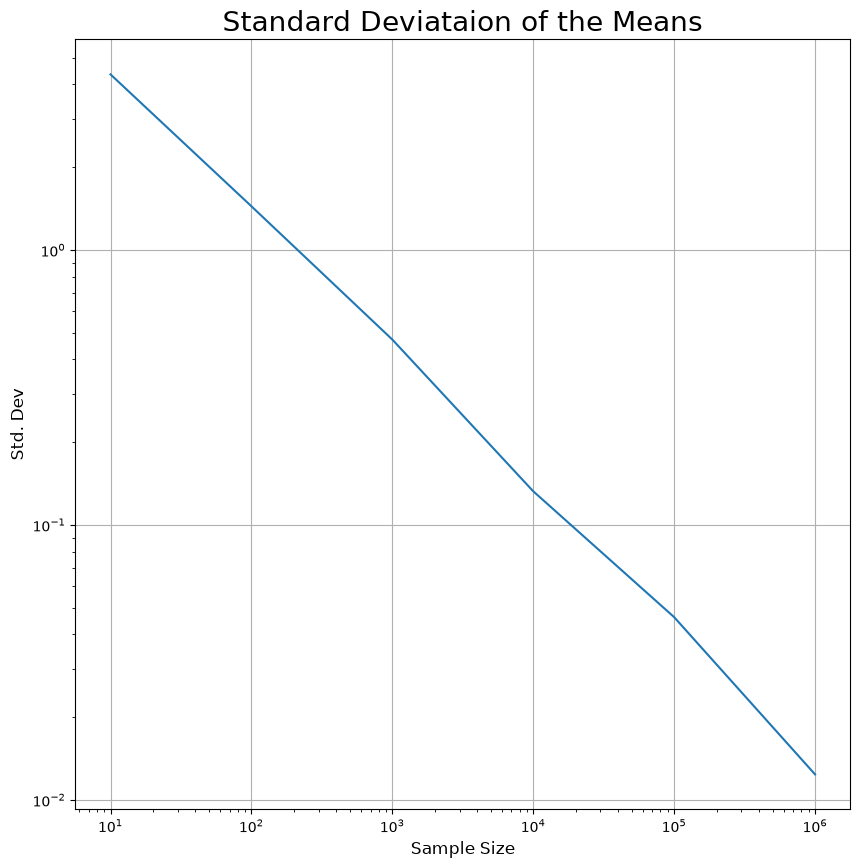

In [11]:
print('\nProblem 7:')

# get x and y from dat_array
x = dat_arr.T[0]
y = dat_arr.T[1]

# create plot
plt.figure( figsize = (10,10))
plt.loglog(x,y)
plt.grid()

# add titles and axis labels
plt.title( 'Standard Deviataion of the Means', fontsize = 20 )
plt.xlabel( 'Sample Size', fontsize = 12 )
plt.ylabel( 'Std. Dev', fontsize = 12 )

# save the figure 
plt.savefig('p2_rab_problem7_graph1.png')

# show the figure
plt.show()